In [1]:
# %% [markdown]
# # lab1b: 회로 결과를 읽는 3가지 방법
# ### 양자 머신러닝 실습 (PennyLane · Colab) — lab1과 lab2 사이 보충
#
# 같은 회로 RX(θ)|0⟩ 를 놓고, QNode가 결과를 돌려주는 **세 가지 반환 방식**을 비교한다.
#
# | 반환 | 무엇을 주나 | 언제 쓰나 |
# |---|---|---|
# | `qml.probs`  | 각 결과의 확률 분포 | 측정 전 상태를 확률로 볼 때 |
# | `qml.sample` | 샷마다의 개별 측정값 | 실제 측정(붕괴)을 볼 때 |
# | `qml.expval` | 관측량의 기댓값 | 하나의 대푯값·비용함수가 필요할 때 |
#
# lab1(오차 스케일링)과 겹치지 않도록, 여기서는 '세 반환의 차이'에만 집중한다.
# (그림 라벨은 영어, 코드 주석/출력은 한글)

# %%
# 설치 — Colab에서 최초 1회만: 아래 줄의 주석을 해제해 실행
!pip install -q pennylane


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 102.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 132.8 MB/s eta 0:00:00


In [2]:

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")


In [3]:

# ---- 공통 설정 ----
theta = np.pi / 4          # 회전각 (pi/6, pi/2, pi 등으로 바꿔보기)
shots = 1024               # 측정 횟수 (10, 100, 10000 으로 바꿔보기)
dev = qml.device("default.qubit", wires=1, seed=1234)

theory_p0 = float(np.cos(theta / 2) ** 2)   # P(|0>)
theory_z = float(np.cos(theta))             # <Z>


@qml.qnode(dev)
def circuit_probs(a):
    qml.RX(a, 0)
    return qml.probs(wires=0)


@qml.qnode(dev)
def circuit_sample(a):
    qml.RX(a, 0)
    return qml.sample(qml.PauliZ(0))   # +1 = |0>, -1 = |1>


@qml.qnode(dev)
def circuit_expval(a):
    qml.RX(a, 0)
    return qml.expval(qml.PauliZ(0))


print("=" * 55)
print(f"  lab1b: 측정 3종  (theta={theta:.3f}, shots={shots})")
print("=" * 55)



  lab1b: 측정 3종  (theta=0.785, shots=1024)



[1b-1] probs — 각 결과가 나올 확률 분포
  P(|0>) = 0.8486   이론 cos^2(θ/2) = 0.8536
  P(|1>) = 0.1514   이론 sin^2(θ/2) = 0.1464


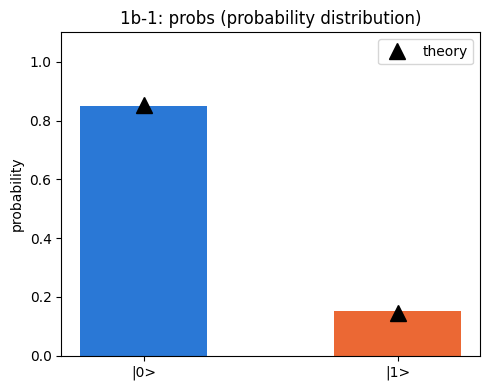

In [4]:

# %%
# ===========================================================
#  1b-1: probs — 측정 전, '확률'로 존재한다
# ===========================================================
print("\n[1b-1] probs — 각 결과가 나올 확률 분포")

p = qml.set_shots(circuit_probs, shots=shots)(theta)
print(f"  P(|0>) = {float(p[0]):.4f}   이론 cos^2(θ/2) = {theory_p0:.4f}")
print(f"  P(|1>) = {float(p[1]):.4f}   이론 sin^2(θ/2) = {1-theory_p0:.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["|0>", "|1>"], [float(p[0]), float(p[1])],
              color=["#2a78d6", "#eb6834"], width=0.5)
ax.plot(["|0>", "|1>"], [theory_p0, 1 - theory_p0], "k^", ms=12, zorder=5, label="theory")
ax.set_ylim(0, 1.1)
ax.set_ylabel("probability")
ax.set_title("1b-1: probs (probability distribution)")
ax.legend()
plt.tight_layout()
plt.show()




[1b-2] sample — 샷마다의 개별 측정 결과 (+1 또는 -1)
  +1(|0>) 비율 = 0.8545   (probs P(|0>) = 0.8486)
  -1(|1>) 비율 = 0.1455   (probs P(|1>) = 0.1514)
  => 개별 측정은 무작위지만, 비율은 probs 로 수렴한다.


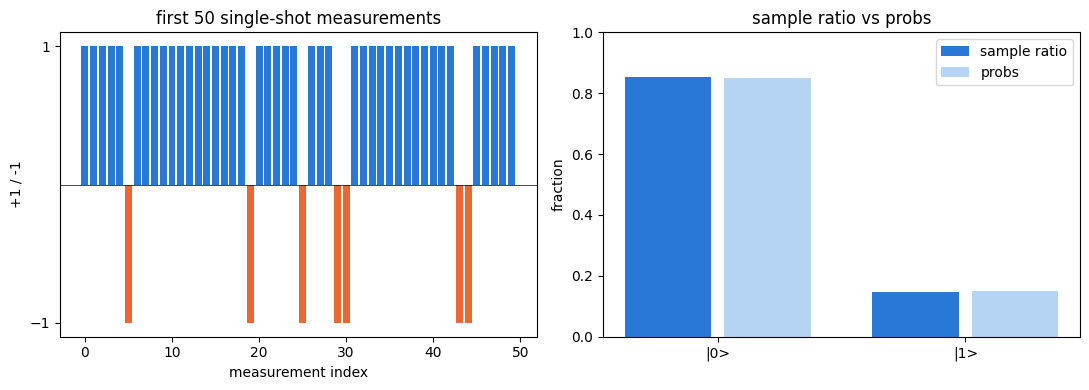

In [5]:

# %%
# ===========================================================
#  1b-2: sample — 측정 순간, 고전값으로 collapse
# ===========================================================
print("\n[1b-2] sample — 샷마다의 개별 측정 결과 (+1 또는 -1)")

s = qml.set_shots(circuit_sample, shots=shots)(theta)
r_p1 = float(np.mean(s == 1))    # +1(|0>) 비율
r_m1 = float(np.mean(s == -1))   # -1(|1>) 비율
print(f"  +1(|0>) 비율 = {r_p1:.4f}   (probs P(|0>) = {float(p[0]):.4f})")
print(f"  -1(|1>) 비율 = {r_m1:.4f}   (probs P(|1>) = {float(p[1]):.4f})")
print("  => 개별 측정은 무작위지만, 비율은 probs 로 수렴한다.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
disp = s[:50]
ax1.bar(range(len(disp)), disp,
        color=["#2a78d6" if v == 1 else "#eb6834" for v in disp], width=0.8)
ax1.axhline(0, color="black", lw=0.5)
ax1.set_yticks([1, -1])
ax1.set_xlabel("measurement index")
ax1.set_ylabel("+1 / -1")
ax1.set_title("first 50 single-shot measurements")

x = std_np.arange(2)
ax2.bar(x - 0.2, [r_p1, r_m1], 0.35, color="#2a78d6", label="sample ratio")
ax2.bar(x + 0.2, [float(p[0]), float(p[1])], 0.35, color="#b5d4f4", label="probs")
ax2.set_xticks(x)
ax2.set_xticklabels(["|0>", "|1>"])
ax2.set_ylim(0, 1)
ax2.set_ylabel("fraction")
ax2.set_title("sample ratio vs probs")
ax2.legend()
plt.tight_layout()
plt.show()




[1b-3] expval — 관측량 Z 의 기댓값 (비용함수로 자주 쓰임)
  <Z> = 0.7285   이론 cos(θ) = 0.7071   차이 = 0.0214
  참고: <Z> = P(|0>) - P(|1>) 이므로 probs 로부터도 얻을 수 있다.


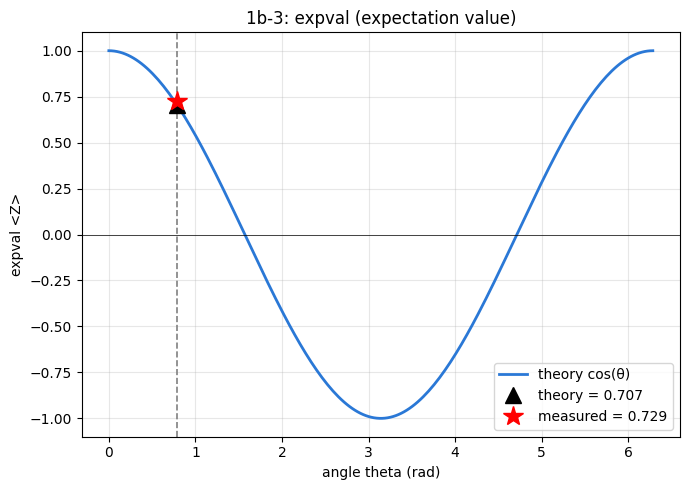


  정리: probs=확률분포 / sample=개별측정 / expval=대푯값
  theta, shots 를 바꿔가며 셋의 관계를 관찰해보세요.


In [6]:

# %%
# ===========================================================
#  1b-3: expval — 하나의 대푯값 (회로 = 수식)
# ===========================================================
print("\n[1b-3] expval — 관측량 Z 의 기댓값 (비용함수로 자주 쓰임)")

ev = float(qml.set_shots(circuit_expval, shots=shots)(theta))
print(f"  <Z> = {ev:.4f}   이론 cos(θ) = {theory_z:.4f}   차이 = {abs(ev-theory_z):.4f}")
print("  참고: <Z> = P(|0>) - P(|1>) 이므로 probs 로부터도 얻을 수 있다.")

angles = std_np.linspace(0, 2 * np.pi, 200)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(angles, std_np.cos(angles), "-", color="#2a78d6", lw=2, label="theory cos(θ)")
ax.axvline(theta, color="gray", ls="--", lw=1.2)
ax.plot(theta, theory_z, "k^", ms=12, zorder=5, label=f"theory = {theory_z:.3f}")
ax.plot(theta, ev, "r*", ms=15, zorder=5, label=f"measured = {ev:.3f}")
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("angle theta (rad)")
ax.set_ylabel("expval <Z>")
ax.set_title("1b-3: expval (expectation value)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 55)
print("  정리: probs=확률분포 / sample=개별측정 / expval=대푯값")
print("  theta, shots 를 바꿔가며 셋의 관계를 관찰해보세요.")
print("=" * 55)